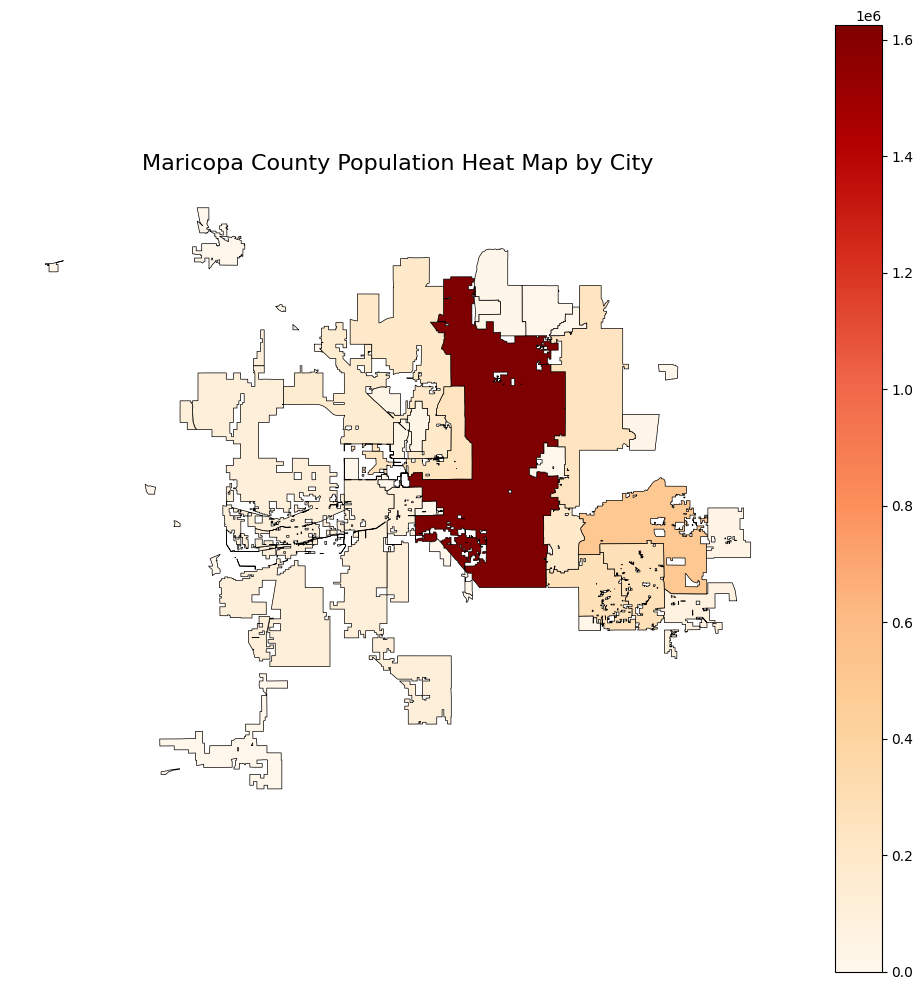

In [ ]:
# Install geopandas in Colab if needed
!pip -q install geopandas

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# -----------------------------
# 1 Load Excel population data
# -----------------------------
excel_file = "/content/Geographic mobility.xlsx"
df = pd.read_excel(excel_file, sheet_name="Data")

header_row = df.iloc[1]
population_row = df.iloc[2]

city_columns = []
for col in df.columns:
    if col != "Unnamed: 0" and header_row[col] == "Estimate" and not str(col).startswith("Unnamed"):
        city_columns.append(col)

populations = {}
for col in city_columns:
    value = str(population_row[col]).replace(",", "")
    populations[col] = pd.to_numeric(value, errors="coerce")

population_df = pd.Series(populations).dropna().reset_index()
population_df.columns = ["city_full", "population"]

# Clean names to match shapefile NAME column
population_df["city_name"] = (
    population_df["city_full"]
    .str.replace(", Arizona", "", regex=False)
    .str.replace(" city", "", regex=False)
    .str.replace(" town", "", regex=False)
    .str.replace(" CDP", "", regex=False)
    .str.strip()
)

# -----------------------------
# 2 Load Arizona place shapefile
# -----------------------------
shape_file = "/content/cb_2020_04_place_500k.shp"
gdf = gpd.read_file(shape_file)

gdf["city_name"] = gdf["NAME"].str.strip()

# -----------------------------
# 3 Merge
# -----------------------------
map_df = gdf.merge(population_df, on="city_name", how="left")

# -----------------------------
# 4 Keep only Maricopa County places from your dataset
# -----------------------------
maricopa_places = [
    "Aguila",
    "Anthem",
    "Apache Junction",
    "Arlington",
    "Avondale",
    "Buckeye",
    "Carefree",
    "Cave Creek",
    "Chandler",
    "Circle City",
    "Citrus Park",
    "El Mirage",
    "Fountain Hills",
    "Gila Bend",
    "Gila Crossing",
    "Gilbert",
    "Glendale",
    "Goodyear",
    "Guadalupe",
    "Komatke",
    "Litchfield Park",
    "Maricopa Colony",
    "Mesa",
    "Morristown",
    "New River",
    "Paradise Valley",
    "Peoria",
    "Phoenix",
    "Queen Creek",
    "Rio Verde",
    "Scottsdale",
    "Sun City",
    "Sun City West",
    "Sun Lakes",
    "Surprise",
    "Tempe",
    "Theba",
    "Tolleson",
    "Tonopah",
    "Wickenburg",
    "Wintersburg",
    "Wittmann",
    "Youngtown"
]

map_df = map_df[map_df["city_name"].isin(maricopa_places)].copy()

# -----------------------------
# 5 Plot only Maricopa County places
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))

map_df.plot(
    column="population",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Maricopa County Population Heat Map by City", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

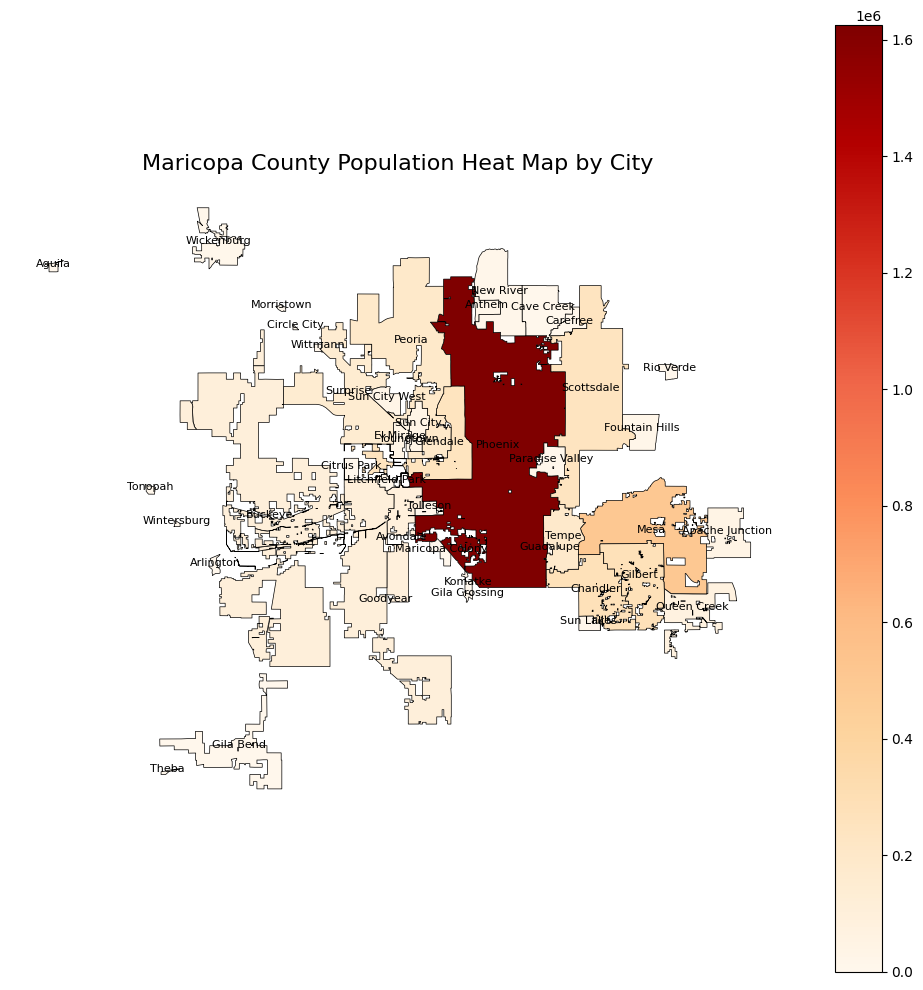

In [ ]:
# -----------------------------
# 5 Plot map and add city labels
# -----------------------------
fig, ax = plt.subplots(figsize=(10,10))

map_df.plot(
    column="population",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

# Add city name labels
for idx, row in map_df.iterrows():
    if pd.notna(row["population"]):
        x = row.geometry.centroid.x
        y = row.geometry.centroid.y

        ax.text(
            x,
            y,
            row["city_name"],
            fontsize=8,
            ha="center"
        )

ax.set_title("Maricopa County Population Heat Map by City", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# === 1. Load the Excel file ===
file_path = "Geographic mobility.xlsx"   # change if needed
df = pd.read_excel(file_path, sheet_name="Data")

# === 2. Helper functions ===
def parse_pct(x):
    """Convert values like '4.5%' into float 4.5"""
    if pd.isna(x):
        return np.nan
    s = str(x).replace("%", "").replace(",", "").strip()
    if s in ["-", "**", "", "nan", "None"]:
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def parse_num(x):
    """Convert values like '186,400' into float 186400"""
    if pd.isna(x):
        return np.nan
    s = str(x).replace(",", "").replace("±", "").strip()
    if s in ["-", "**", "", "nan", "None"]:
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

# === 3. Extract each city block ===
# In your sheet, each city starts at columns 1, 11, 21, ...
records = []

for start in range(1, df.shape[1], 10):
    place = df.columns[start]

    # row 2 = total population 1 year and over
    total_pop = parse_num(df.iloc[2, start])

    # movement percentages from row 2
    within_same_county = parse_pct(df.iloc[2, start + 2])
    from_diff_county_same_state = parse_pct(df.iloc[2, start + 4])
    from_diff_state = parse_pct(df.iloc[2, start + 6])
    from_abroad = parse_pct(df.iloc[2, start + 8])

    # same house = 100 - all movers
    moved_total = np.nansum([
        within_same_county,
        from_diff_county_same_state,
        from_diff_state,
        from_abroad
    ])
    same_house = 100 - moved_total

    # attraction = outside inflow
    attraction = np.nansum([
        from_diff_county_same_state,
        from_diff_state,
        from_abroad
    ])

    records.append({
        "place": place,
        "population_1y_over": total_pop,
        "within_same_county_pct": within_same_county,
        "from_diff_county_same_state_pct": from_diff_county_same_state,
        "from_diff_state_pct": from_diff_state,
        "from_abroad_pct": from_abroad,
        "same_house_pct": same_house,
        "attraction_pct": attraction
    })

prosperity_df = pd.DataFrame(records)

# === 4. Optional: keep only larger places to reduce noise ===
# Tiny CDPs can distort the ranking, so this filter helps.
prosperity_df = prosperity_df[prosperity_df["population_1y_over"] >= 5000].copy()

# === 5. Normalize indicators to 0-100 ===
def minmax(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

prosperity_df["attraction_norm"] = minmax(prosperity_df["attraction_pct"])
prosperity_df["stability_norm"] = minmax(prosperity_df["same_house_pct"])
prosperity_df["internal_mobility_norm"] = minmax(prosperity_df["within_same_county_pct"])

# === 6. Prosperity Index formula ===
# You can adjust weights if needed
prosperity_df["prosperity_index"] = (
    0.50 * prosperity_df["attraction_norm"] +
    0.30 * prosperity_df["stability_norm"] +
    0.20 * prosperity_df["internal_mobility_norm"]
)

# === 7. Sort from highest to lowest ===
prosperity_df = prosperity_df.sort_values("prosperity_index", ascending=False)

# === 8. Show top results ===
print("Top places by Prosperity Index:")
display(
    prosperity_df[
        [
            "place",
            "population_1y_over",
            "attraction_pct",
            "same_house_pct",
            "within_same_county_pct",
            "prosperity_index"
        ]
    ].head(15)
)

# === 9. Focus on major Maricopa County cities/towns ===
major_places = [
    "Tempe city, Arizona",
    "Scottsdale city, Arizona",
    "Chandler city, Arizona",
    "Gilbert town, Arizona",
    "Mesa city, Arizona",
    "Phoenix city, Arizona",
    "Glendale city, Arizona",
    "Buckeye city, Arizona",
    "Goodyear city, Arizona",
    "Queen Creek town, Arizona",
    "Avondale city, Arizona"
]

major_df = prosperity_df[prosperity_df["place"].isin(major_places)].copy()
major_df = major_df.sort_values("prosperity_index", ascending=False)

print("\nMajor Maricopa County places:")
display(
    major_df[
        [
            "place",
            "population_1y_over",
            "attraction_pct",
            "same_house_pct",
            "within_same_county_pct",
            "prosperity_index"
        ]
    ]
)

Top places by Prosperity Index:


,place,population_1y_over,attraction_pct,same_house_pct,within_same_county_pct,prosperity_index
2,"Apache Junction city, Arizona",40741.0,10.3,86.4,3.3,68.776596
7,"Cave Creek town, Arizona",5091.0,9.6,83.1,7.3,66.097413
37,"Tempe city, Arizona",186400.0,9.0,74.5,16.5,63.500000
41,"Wickenburg town, Arizona",8059.0,7.8,89.8,2.4,60.000000
12,"Fountain Hills town, Arizona",23733.0,7.7,89.3,3.0,59.615770
39,"Tolleson city, Arizona",7582.0,6.4,84.9,8.7,54.730288
35,"Sun Lakes CDP, Arizona",13924.0,6.3,88.5,5.2,54.559866
32,"Scottsdale city, Arizona",241921.0,6.1,84.2,9.7,53.619316
5,"Buckeye city, Arizona",103593.0,5.6,89.1,5.3,52.084063
29,"Queen Creek town, Arizona",71165.0,5.6,88.1,6.3,52.031915



Major Maricopa County places:


,place,population_1y_over,attraction_pct,same_house_pct,within_same_county_pct,prosperity_index
37,"Tempe city, Arizona",186400.0,9.0,74.5,16.5,63.500000
32,"Scottsdale city, Arizona",241921.0,6.1,84.2,9.7,53.619316
5,"Buckeye city, Arizona",103593.0,5.6,89.1,5.3,52.084063
29,"Queen Creek town, Arizona",71165.0,5.6,88.1,6.3,52.031915
15,"Gilbert town, Arizona",277500.0,5.4,86.2,8.4,51.216521
23,"Mesa city, Arizona",506004.0,5.3,84.4,10.3,50.764497
8,"Chandler city, Arizona",277540.0,4.7,86.6,8.7,48.730288
17,"Goodyear city, Arizona",106285.0,4.5,88.0,7.5,48.086984
28,"Phoenix city, Arizona",1625143.0,4.3,85.4,10.3,47.235086
16,"Glendale city, Arizona",249978.0,4.2,88.3,7.5,47.028160


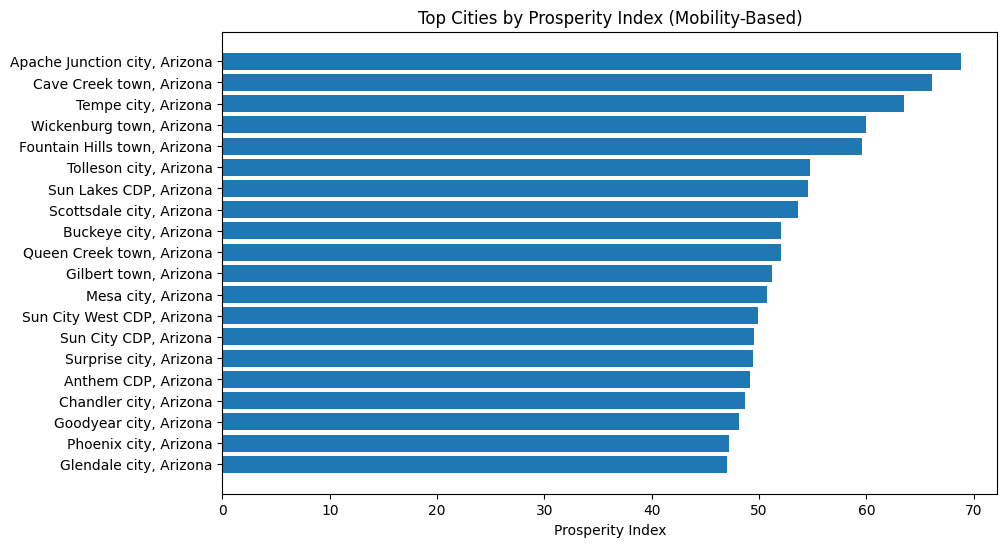

In [ ]:
import matplotlib.pyplot as plt

# Select top 15 cities
top_cities = prosperity_df.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_cities["place"], top_cities["prosperity_index"])

plt.xlabel("Prosperity Index")
plt.title("Top Cities by Prosperity Index (Mobility-Based)")
plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Sort cities by population from highest to lowest
population_sorted = prosperity_df.sort_values(
    by="population_1y_over",
    ascending=False
)

# Display results
population_sorted[["place", "population_1y_over"]]

,place,population_1y_over
28,"Phoenix city, Arizona",1625143.0
23,"Mesa city, Arizona",506004.0
8,"Chandler city, Arizona",277540.0
15,"Gilbert town, Arizona",277500.0
16,"Glendale city, Arizona",249978.0
32,"Scottsdale city, Arizona",241921.0
27,"Peoria city, Arizona",195038.0
37,"Tempe city, Arizona",186400.0
36,"Surprise city, Arizona",153384.0
17,"Goodyear city, Arizona",106285.0


In [ ]:
# Calculate total population
total_population = population_sorted["population_1y_over"].sum()

# Create percentage column
population_sorted["population_percent"] = (
    population_sorted["population_1y_over"] / total_population * 100
)

# Show results
population_sorted[["place", "population_1y_over", "population_percent"]]


,place,population_1y_over,population_percent
28,"Phoenix city, Arizona",1625143.0,37.255534
23,"Mesa city, Arizona",506004.0,11.599871
8,"Chandler city, Arizona",277540.0,6.362456
15,"Gilbert town, Arizona",277500.0,6.361539
16,"Glendale city, Arizona",249978.0,5.730612
32,"Scottsdale city, Arizona",241921.0,5.545909
27,"Peoria city, Arizona",195038.0,4.471142
37,"Tempe city, Arizona",186400.0,4.273120
36,"Surprise city, Arizona",153384.0,3.516246
17,"Goodyear city, Arizona",106285.0,2.436527


In [ ]:
# Create final table directly from population_sorted
final_table = population_sorted[[
    "place",
    "population_1y_over",
    "population_percent",
    "prosperity_index"
]].copy()

# Keep only cities with more than 1% of total population
final_table = final_table[final_table["population_percent"] > 1].copy()

# Rename columns
final_table = final_table.rename(columns={
    "place": "City",
    "population_1y_over": "Population",
    "population_percent": "Population (%)",
    "prosperity_index": "Prosperity Index"
})

# Sort from most to least population
final_table = final_table.sort_values(by="Population", ascending=False)

# Round for cleaner display
final_table["Population (%)"] = final_table["Population (%)"].round(2)
final_table["Prosperity Index"] = final_table["Prosperity Index"].round(2)

# Reset index
final_table = final_table.reset_index(drop=True)

# Show result
final_table

,City,Population,Population (%),Prosperity Index
0,"Phoenix city, Arizona",1625143.0,37.26,47.24
1,"Mesa city, Arizona",506004.0,11.60,50.76
2,"Chandler city, Arizona",277540.0,6.36,48.73
3,"Gilbert town, Arizona",277500.0,6.36,51.22
4,"Glendale city, Arizona",249978.0,5.73,47.03
5,"Scottsdale city, Arizona",241921.0,5.55,53.62
6,"Peoria city, Arizona",195038.0,4.47,43.11
7,"Tempe city, Arizona",186400.0,4.27,63.50
8,"Surprise city, Arizona",153384.0,3.52,49.42
9,"Goodyear city, Arizona",106285.0,2.44,48.09


In [ ]:
#Overall prosperity index
average_prosperity = population_sorted["prosperity_index"].mean()

average_prosperity

np.float64(49.762900464661286)

In [ ]:
avg = final_table["Prosperity Index"].mean()

final_table["Prosperity Level"] = final_table["Prosperity Index"].apply(
    lambda x: "Above Average" if x > avg else "Below Average"
)

final_table

,City,Population,Population (%),Prosperity Index,Prosperity Level
0,"Phoenix city, Arizona",1625143.0,37.26,47.24,Below Average
1,"Mesa city, Arizona",506004.0,11.60,50.76,Above Average
2,"Chandler city, Arizona",277540.0,6.36,48.73,Below Average
3,"Gilbert town, Arizona",277500.0,6.36,51.22,Above Average
4,"Glendale city, Arizona",249978.0,5.73,47.03,Below Average
5,"Scottsdale city, Arizona",241921.0,5.55,53.62,Above Average
6,"Peoria city, Arizona",195038.0,4.47,43.11,Below Average
7,"Tempe city, Arizona",186400.0,4.27,63.50,Above Average
8,"Surprise city, Arizona",153384.0,3.52,49.42,Below Average
9,"Goodyear city, Arizona",106285.0,2.44,48.09,Below Average


In [ ]:
# Create a prosperity ranking table
prosperity_ranking = final_table.sort_values(
    by="Prosperity Index",
    ascending=False
).reset_index(drop=True)

prosperity_ranking

,City,Population,Population (%),Prosperity Index,Prosperity Level
0,"Tempe city, Arizona",186400.0,4.27,63.50,Above Average
1,"Scottsdale city, Arizona",241921.0,5.55,53.62,Above Average
2,"Buckeye city, Arizona",103593.0,2.37,52.08,Above Average
3,"Queen Creek town, Arizona",71165.0,1.63,52.03,Above Average
4,"Gilbert town, Arizona",277500.0,6.36,51.22,Above Average
5,"Mesa city, Arizona",506004.0,11.60,50.76,Above Average
6,"Surprise city, Arizona",153384.0,3.52,49.42,Below Average
7,"Chandler city, Arizona",277540.0,6.36,48.73,Below Average
8,"Goodyear city, Arizona",106285.0,2.44,48.09,Below Average
9,"Phoenix city, Arizona",1625143.0,37.26,47.24,Below Average


In [ ]:
# Create attraction index table for cities with >1% population
attraction_table = population_sorted[
    population_sorted["population_percent"] > 1
][[
    "place",
    "population_1y_over",
    "population_percent",
    "attraction_pct"
]].copy()

# Rename columns for readability
attraction_table = attraction_table.rename(columns={
    "place": "City",
    "population_1y_over": "Population",
    "population_percent": "Population (%)",
    "attraction_pct": "Attraction Index (%)"
})

# Sort from highest attraction to lowest
attraction_table = attraction_table.sort_values(
    by="Attraction Index (%)",
    ascending=False
).reset_index(drop=True)

# Round percentages
attraction_table["Population (%)"] = attraction_table["Population (%)"].round(2)
attraction_table["Attraction Index (%)"] = attraction_table["Attraction Index (%)"].round(2)

# Show table
attraction_table

,City,Population,Population (%),Attraction Index (%)
0,"Tempe city, Arizona",186400.0,4.27,9.0
1,"Scottsdale city, Arizona",241921.0,5.55,6.1
2,"Buckeye city, Arizona",103593.0,2.37,5.6
3,"Queen Creek town, Arizona",71165.0,1.63,5.6
4,"Gilbert town, Arizona",277500.0,6.36,5.4
5,"Mesa city, Arizona",506004.0,11.60,5.3
6,"Surprise city, Arizona",153384.0,3.52,4.9
7,"Chandler city, Arizona",277540.0,6.36,4.7
8,"Goodyear city, Arizona",106285.0,2.44,4.5
9,"Phoenix city, Arizona",1625143.0,37.26,4.3


In [ ]:
# Create stability index table for major cities (>1% population)
stability_table = population_sorted[
    population_sorted["population_percent"] > 1
][[
    "place",
    "population_1y_over",
    "population_percent",
    "same_house_pct"
]].copy()

# Rename columns
stability_table = stability_table.rename(columns={
    "place": "City",
    "population_1y_over": "Population",
    "population_percent": "Population (%)",
    "same_house_pct": "Stability Index (%)"
})

# Sort from highest stability to lowest
stability_table = stability_table.sort_values(
    by="Stability Index (%)",
    ascending=False
).reset_index(drop=True)

# Round numbers
stability_table["Population (%)"] = stability_table["Population (%)"].round(2)
stability_table["Stability Index (%)"] = stability_table["Stability Index (%)"].round(2)

# Show table
stability_table

,City,Population,Population (%),Stability Index (%)
0,"Buckeye city, Arizona",103593.0,2.37,89.1
1,"Peoria city, Arizona",195038.0,4.47,88.7
2,"Glendale city, Arizona",249978.0,5.73,88.3
3,"Queen Creek town, Arizona",71165.0,1.63,88.1
4,"Goodyear city, Arizona",106285.0,2.44,88.0
5,"Avondale city, Arizona",91344.0,2.09,87.7
6,"Chandler city, Arizona",277540.0,6.36,86.6
7,"Gilbert town, Arizona",277500.0,6.36,86.2
8,"Surprise city, Arizona",153384.0,3.52,86.1
9,"Phoenix city, Arizona",1625143.0,37.26,85.4


In [ ]:
# Create internal mobility table for major cities (>1% population)
mobility_table = population_sorted[
    population_sorted["population_percent"] > 1
][[
    "place",
    "population_1y_over",
    "population_percent",
    "within_same_county_pct"
]].copy()

# Rename columns
mobility_table = mobility_table.rename(columns={
    "place": "City",
    "population_1y_over": "Population",
    "population_percent": "Population (%)",
    "within_same_county_pct": "Internal Mobility Index (%)"
})

# Sort from highest mobility to lowest
mobility_table = mobility_table.sort_values(
    by="Internal Mobility Index (%)",
    ascending=False
).reset_index(drop=True)

# Round values
mobility_table["Population (%)"] = mobility_table["Population (%)"].round(2)
mobility_table["Internal Mobility Index (%)"] = mobility_table["Internal Mobility Index (%)"].round(2)

# Display table
mobility_table

,City,Population,Population (%),Internal Mobility Index (%)
0,"Tempe city, Arizona",186400.0,4.27,16.5
1,"Mesa city, Arizona",506004.0,11.60,10.3
2,"Phoenix city, Arizona",1625143.0,37.26,10.3
3,"Scottsdale city, Arizona",241921.0,5.55,9.7
4,"Surprise city, Arizona",153384.0,3.52,9.0
5,"Chandler city, Arizona",277540.0,6.36,8.7
6,"Gilbert town, Arizona",277500.0,6.36,8.4
7,"Peoria city, Arizona",195038.0,4.47,8.2
8,"Avondale city, Arizona",91344.0,2.09,8.1
9,"Glendale city, Arizona",249978.0,5.73,7.5


In [ ]:
# Create prosperity score table for major cities (>1% population)
prosperity_table = final_table[[
    "City",
    "Population",
    "Population (%)",
    "Prosperity Index"
]].copy()

# Sort from highest prosperity to lowest
prosperity_table = prosperity_table.sort_values(
    by="Prosperity Index",
    ascending=False
).reset_index(drop=True)

# Add ranking column
prosperity_table.insert(0, "Rank", range(1, len(prosperity_table)+1))

# Display table
prosperity_table

,Rank,City,Population,Population (%),Prosperity Index
0,1,"Tempe city, Arizona",186400.0,4.27,63.50
1,2,"Scottsdale city, Arizona",241921.0,5.55,53.62
2,3,"Buckeye city, Arizona",103593.0,2.37,52.08
3,4,"Queen Creek town, Arizona",71165.0,1.63,52.03
4,5,"Gilbert town, Arizona",277500.0,6.36,51.22
5,6,"Mesa city, Arizona",506004.0,11.60,50.76
6,7,"Surprise city, Arizona",153384.0,3.52,49.42
7,8,"Chandler city, Arizona",277540.0,6.36,48.73
8,9,"Goodyear city, Arizona",106285.0,2.44,48.09
9,10,"Phoenix city, Arizona",1625143.0,37.26,47.24


In [ ]:
# Step 1 — Start with major cities (>1% population)
ranking_df = population_sorted[
    population_sorted["population_percent"] > 1
].copy()

# Step 2 — Function to convert numeric values into High / Medium / Low
def categorize(series):
    q1 = series.quantile(0.33)
    q2 = series.quantile(0.66)

    def label(x):
        if x <= q1:
            return "Low"
        elif x <= q2:
            return "Medium"
        else:
            return "High"

    return series.apply(label)

# Step 3 — Create category columns
ranking_df["Attraction"] = categorize(ranking_df["attraction_pct"])
ranking_df["Stability"] = categorize(ranking_df["same_house_pct"])
ranking_df["Mobility"] = categorize(ranking_df["within_same_county_pct"])

# Step 4 — Select columns for the final table
ranking_table = ranking_df[[
    "place",
    "Attraction",
    "Stability",
    "Mobility",
    "prosperity_index"
]].copy()

# Step 5 — Rename columns
ranking_table = ranking_table.rename(columns={
    "place": "City",
    "prosperity_index": "Prosperity Score"
})

# Step 6 — Sort by Prosperity Score
ranking_table = ranking_table.sort_values(
    by="Prosperity Score",
    ascending=False
).reset_index(drop=True)

# Step 7 — Round score
ranking_table["Prosperity Score"] = ranking_table["Prosperity Score"].round(0)

# Display table
ranking_table

,City,Attraction,Stability,Mobility,Prosperity Score
0,"Tempe city, Arizona",High,Low,High,64.0
1,"Scottsdale city, Arizona",High,Low,High,54.0
2,"Buckeye city, Arizona",High,High,Low,52.0
3,"Queen Creek town, Arizona",High,High,Low,52.0
4,"Gilbert town, Arizona",High,Medium,Medium,51.0
5,"Mesa city, Arizona",Medium,Low,High,51.0
6,"Surprise city, Arizona",Medium,Medium,High,49.0
7,"Chandler city, Arizona",Medium,Medium,Medium,49.0
8,"Goodyear city, Arizona",Medium,High,Low,48.0
9,"Phoenix city, Arizona",Low,Low,High,47.0


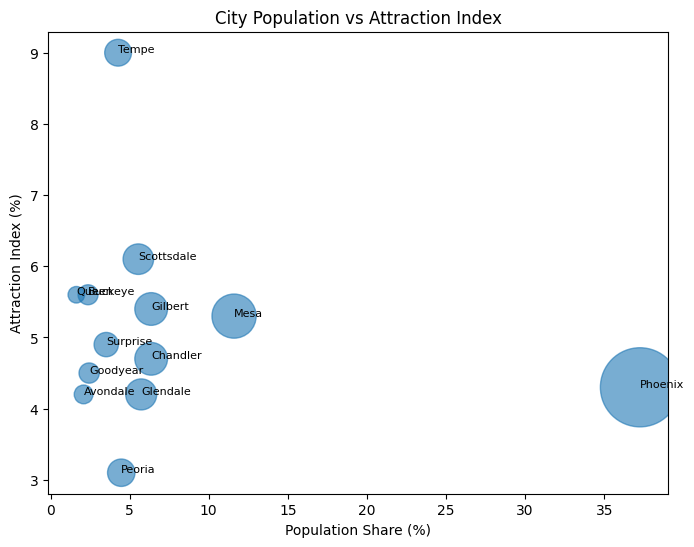

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    attraction_table["Population (%)"],
    attraction_table["Attraction Index (%)"],
    s=attraction_table["Population"]/500,
    alpha=0.6
)

for i, city in enumerate(attraction_table["City"]):
    plt.text(
        attraction_table["Population (%)"].iloc[i],
        attraction_table["Attraction Index (%)"].iloc[i],
        city.split()[0],
        fontsize=8
    )

plt.xlabel("Population Share (%)")
plt.ylabel("Attraction Index (%)")
plt.title("City Population vs Attraction Index")

plt.show()

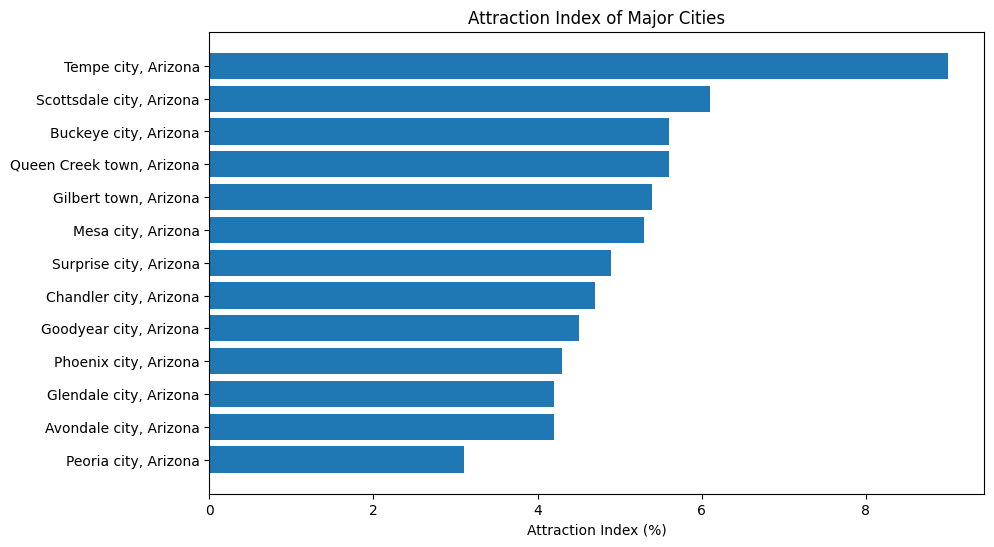

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    attraction_table["City"],
    attraction_table["Attraction Index (%)"]
)

plt.xlabel("Attraction Index (%)")
plt.title("Attraction Index of Major Cities")

plt.gca().invert_yaxis()

plt.show()

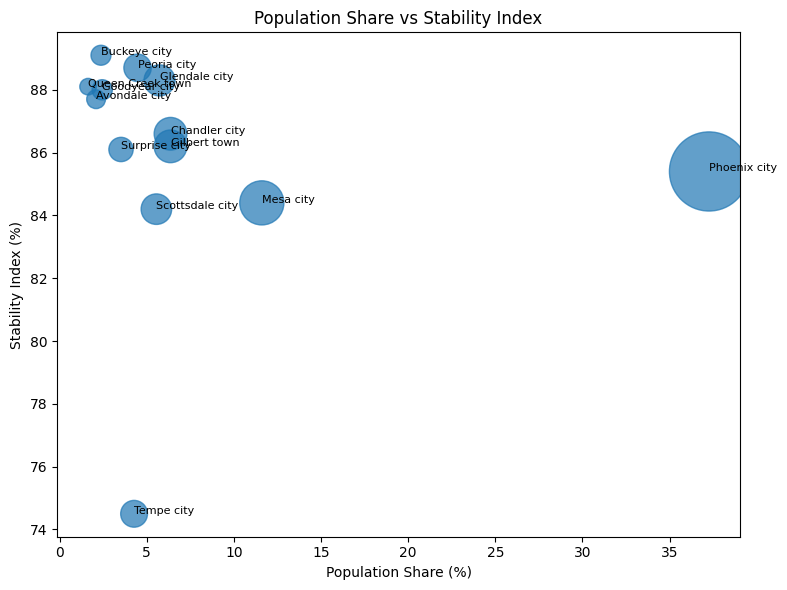

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    stability_table["Population (%)"],
    stability_table["Stability Index (%)"],
    s=stability_table["Population"] / 500,
    alpha=0.7
)

for i, city in enumerate(stability_table["City"]):
    plt.text(
        stability_table["Population (%)"].iloc[i],
        stability_table["Stability Index (%)"].iloc[i],
        city.split(",")[0],
        fontsize=8
    )

plt.xlabel("Population Share (%)")
plt.ylabel("Stability Index (%)")
plt.title("Population Share vs Stability Index")
plt.tight_layout()
plt.show()

In [ ]:
stability_table.style.background_gradient(
    subset=["Stability Index (%)"],
    cmap="Blues"
)

,City,Population,Population (%),Stability Index (%)
0,"Buckeye city, Arizona",103593.000000,2.370000,89.100000
1,"Peoria city, Arizona",195038.000000,4.470000,88.700000
2,"Glendale city, Arizona",249978.000000,5.730000,88.300000
3,"Queen Creek town, Arizona",71165.000000,1.630000,88.100000
4,"Goodyear city, Arizona",106285.000000,2.440000,88.000000
5,"Avondale city, Arizona",91344.000000,2.090000,87.700000
6,"Chandler city, Arizona",277540.000000,6.360000,86.600000
7,"Gilbert town, Arizona",277500.000000,6.360000,86.200000
8,"Surprise city, Arizona",153384.000000,3.520000,86.100000
9,"Phoenix city, Arizona",1625143.000000,37.260000,85.400000


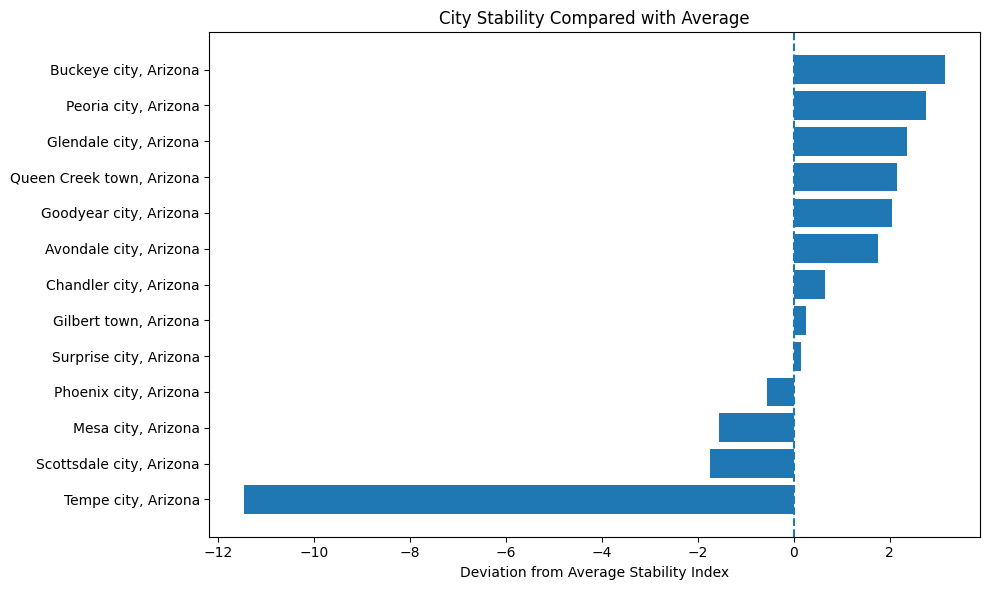

In [ ]:
avg_stability = stability_table["Stability Index (%)"].mean()

stability_dev = stability_table.copy()
stability_dev["Deviation from Avg"] = (
    stability_dev["Stability Index (%)"] - avg_stability
)

stability_dev = stability_dev.sort_values("Deviation from Avg", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(
    stability_dev["City"],
    stability_dev["Deviation from Avg"]
)

plt.axvline(0, linestyle="--")
plt.xlabel("Deviation from Average Stability Index")
plt.title("City Stability Compared with Average")
plt.tight_layout()
plt.show()

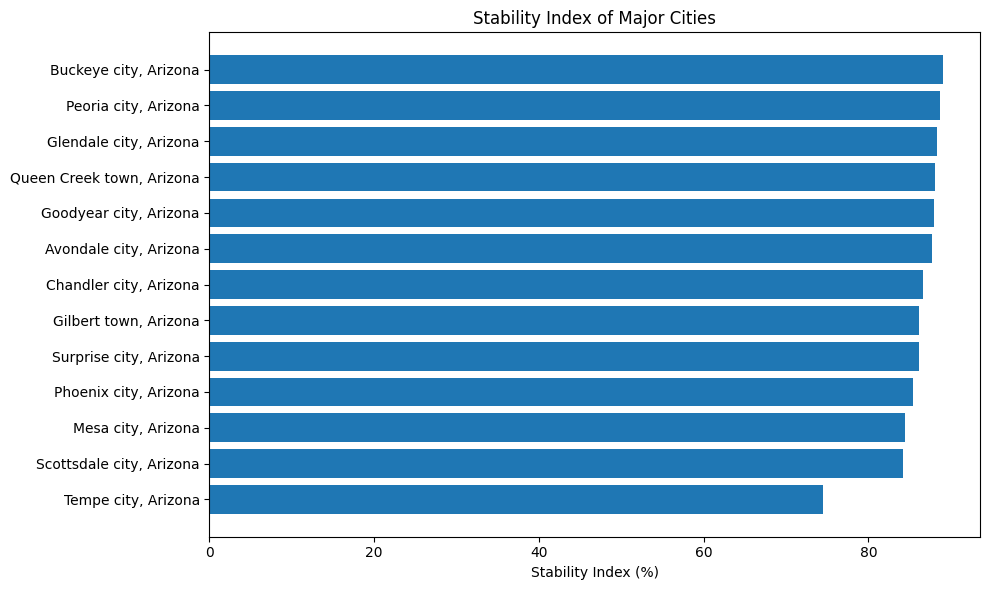

In [ ]:
import matplotlib.pyplot as plt

# Sort from highest to lowest stability
stability_plot = stability_table.sort_values(
    by="Stability Index (%)",
    ascending=True
)

plt.figure(figsize=(10, 6))
plt.barh(
    stability_plot["City"],
    stability_plot["Stability Index (%)"]
)

plt.xlabel("Stability Index (%)")
plt.title("Stability Index of Major Cities")
plt.tight_layout()
plt.show()

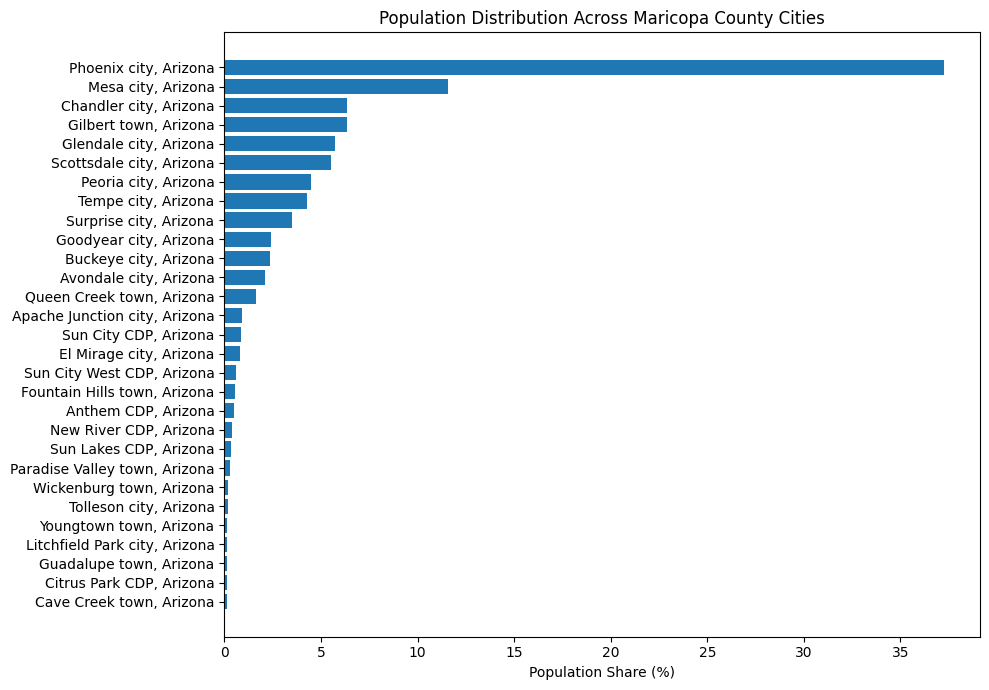

In [ ]:
import matplotlib.pyplot as plt

# Sort by population percentage
pop_plot = population_sorted.sort_values(
    by="population_percent",
    ascending=True
)

plt.figure(figsize=(10,7))

plt.barh(
    pop_plot["place"],
    pop_plot["population_percent"]
)

plt.xlabel("Population Share (%)")
plt.title("Population Distribution Across Maricopa County Cities")

plt.tight_layout()
plt.show()

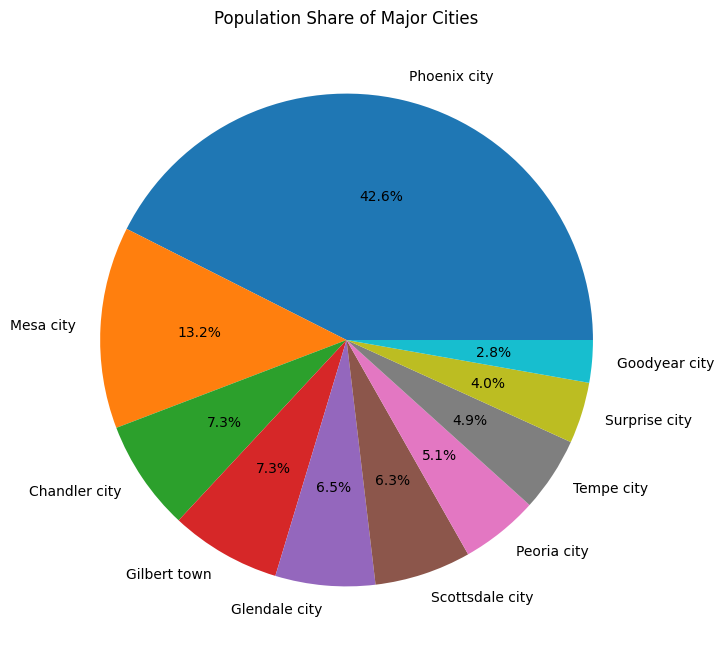

In [ ]:
top_cities = population_sorted.head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_cities["population_percent"],
    labels=top_cities["place"].str.split(",").str[0],
    autopct='%1.1f%%'
)

plt.title("Population Share of Major Cities")
plt.show()

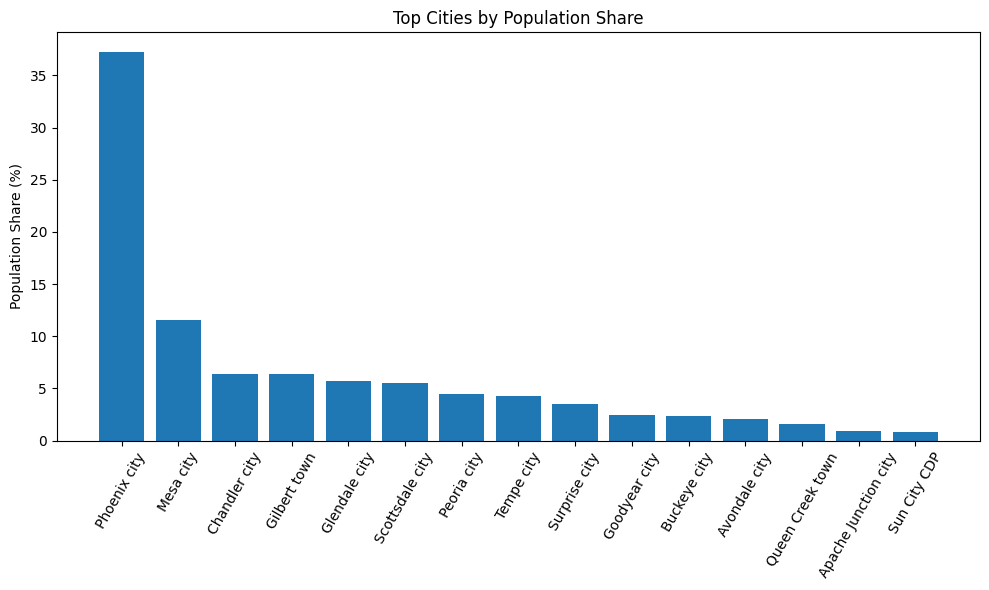

In [ ]:
pop_plot = population_sorted.sort_values(
    by="population_percent",
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

bars = plt.bar(
    pop_plot["place"].str.split(",").str[0],
    pop_plot["population_percent"]
)

plt.xticks(rotation=60)
plt.ylabel("Population Share (%)")
plt.title("Top Cities by Population Share")

plt.tight_layout()
plt.show()

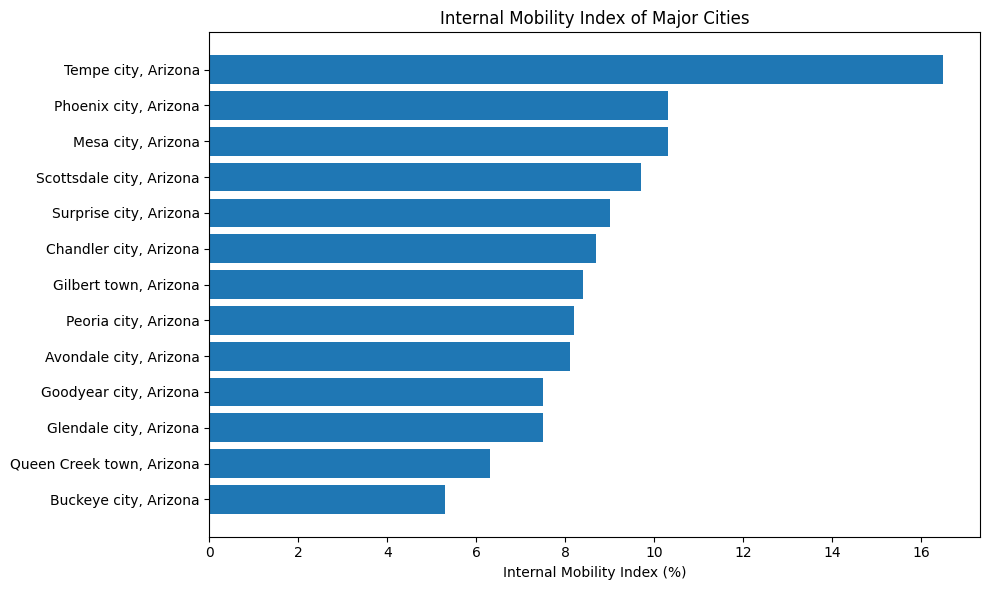

In [ ]:
import matplotlib.pyplot as plt

# Sort by internal mobility
mobility_plot = mobility_table.sort_values(
    by="Internal Mobility Index (%)",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    mobility_plot["City"],
    mobility_plot["Internal Mobility Index (%)"]
)

plt.xlabel("Internal Mobility Index (%)")
plt.title("Internal Mobility Index of Major Cities")

plt.tight_layout()
plt.show()

In [ ]:
comparison_table = population_sorted[
    population_sorted["population_percent"] > 1
][[
    "place",
    "attraction_pct",
    "same_house_pct",
    "within_same_county_pct",
    "prosperity_index"
]].copy()

comparison_table = comparison_table.rename(columns={
    "place": "City",
    "attraction_pct": "Attraction",
    "same_house_pct": "Stability",
    "within_same_county_pct": "Mobility",
    "prosperity_index": "Prosperity"
})

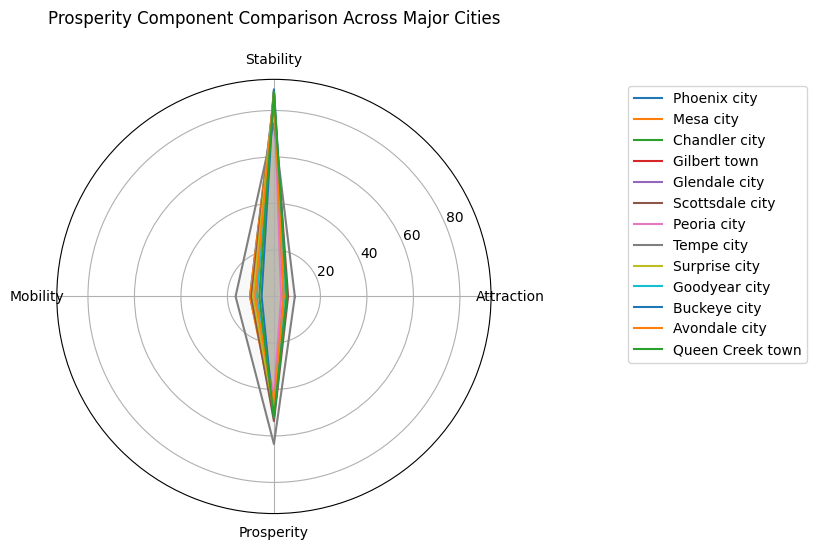

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Use all major cities already stored in comparison_table
data = comparison_table.copy()

categories = ["Attraction", "Stability", "Mobility", "Prosperity"]
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(9,9))
ax = plt.subplot(111, polar=True)

for _, row in data.iterrows():
    values = row[categories].tolist()
    values += values[:1]

    city_name = row["City"].split(",")[0] if "," in row["City"] else row["City"]

    ax.plot(angles, values, linewidth=1.5, label=city_name)
    ax.fill(angles, values, alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("Prosperity Component Comparison Across Major Cities", pad = 40)

plt.legend(bbox_to_anchor=(1.3, 1), loc="upper left")

plt.tight_layout()
plt.show()

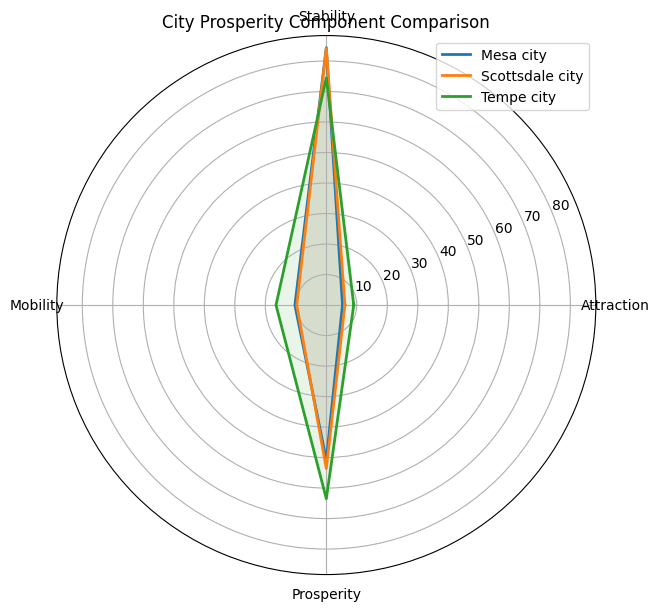

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select cities to compare
cities = ["Tempe city, Arizona", "Scottsdale city, Arizona", "Mesa city, Arizona"]

data = comparison_table[
    comparison_table["City"].isin(cities)
]

categories = ["Attraction", "Stability", "Mobility", "Prosperity"]
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for i, row in data.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=row["City"].split(",")[0])
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("City Prosperity Component Comparison")
plt.legend(loc="upper right")
plt.show()

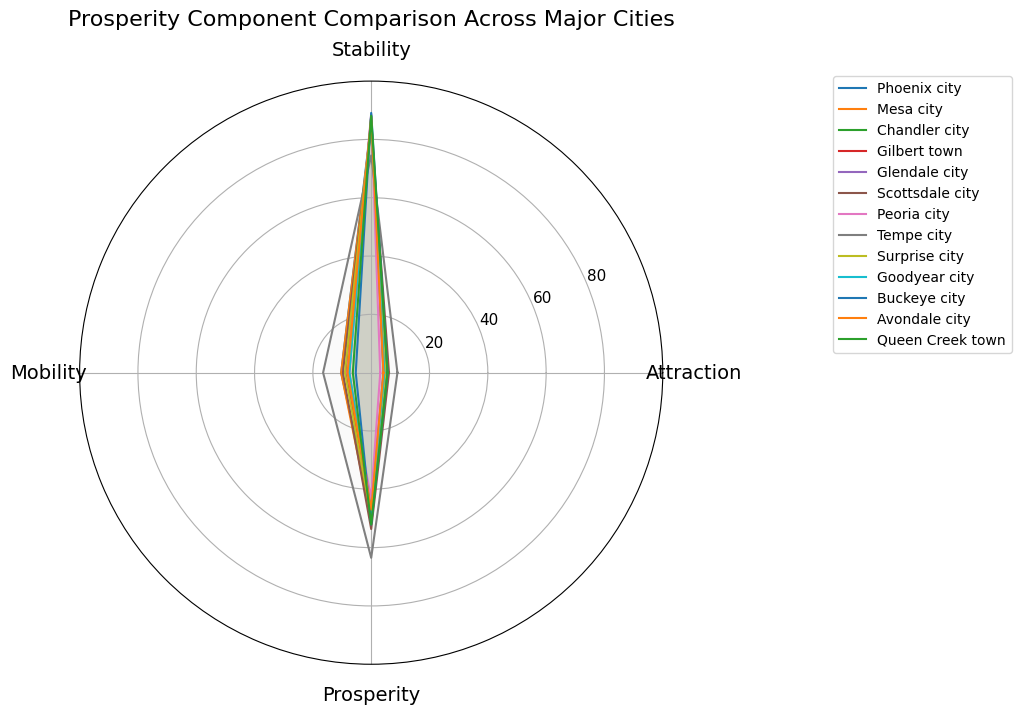

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = comparison_table.copy()

categories = ["Attraction", "Stability", "Mobility", "Prosperity"]
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(11, 11), subplot_kw=dict(polar=True))

for _, row in data.iterrows():
    values = row[categories].tolist()
    values += values[:1]

    city_name = row["City"].split(",")[0] if "," in row["City"] else row["City"]

    ax.plot(angles, values, linewidth=1.5, label=city_name)
    ax.fill(angles, values, alpha=0.03)

# Category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=14)
ax.tick_params(axis='x', pad=12)   # move Attraction/Mobility/Stability/Prosperity outward

# Radial scale
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80])
ax.set_yticklabels(["20", "40", "60", "80"], fontsize=11)
ax.set_rlabel_position(22.5)       # move radial tick labels away from Attraction/Mobility

# Title and legend
ax.set_title("Prosperity Component Comparison Across Major Cities", pad=40, fontsize=16)
plt.legend(bbox_to_anchor=(1.28, 1.02), loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
house_raw = pd.read_excel("/content/Housing Values.xlsx", sheet_name="Data")

def parse_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).replace(",", "").replace("±", "").strip()
    if s in ["-", "**", "", "nan", "None"]:
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

labels = house_raw.iloc[:, 0].astype(str).str.strip()

band_labels = [
    "Less than $10,000",
    "$10,000 to $14,999",
    "$15,000 to $19,999",
    "$20,000 to $24,999",
    "$25,000 to $29,999",
    "$30,000 to $34,999",
    "$35,000 to $39,999",
    "$40,000 to $49,999",
    "$50,000 to $59,999",
    "$60,000 to $69,999",
    "$70,000 to $79,999",
    "$80,000 to $89,999",
    "$90,000 to $99,999",
    "$100,000 to $124,999",
    "$125,000 to $149,999",
    "$150,000 to $174,999",
    "$175,000 to $199,999",
    "$200,000 to $249,999",
    "$250,000 to $299,999",
    "$300,000 to $399,999",
    "$400,000 to $499,999",
    "$500,000 to $749,999",
    "$750,000 to $999,999"
]

midpoints = [
      5000,   12500,   17500,   22500,   27500,   32500,
     37500,   45000,   55000,   65000,   75000,   85000,
     95000,  112500,  137500,  162500,  187500,  225000,
    275000,  350000,  450000,  625000,  875000
]

band_rows = {}
for lbl in band_labels:
    matches = house_raw.index[labels == lbl].tolist()
    if matches:
        band_rows[lbl] = matches[0]

house_records = []

# HOUSING FILE: 2 columns per city (Estimate + MOE)
for start in range(1, house_raw.shape[1], 2):
    place = house_raw.columns[start]

    counts = []
    used_midpoints = []

    for lbl, midpoint in zip(band_labels, midpoints):
        if lbl in band_rows:
            row_idx = band_rows[lbl]
            count = parse_num(house_raw.iloc[row_idx, start])  # estimate column
            counts.append(count)
            used_midpoints.append(midpoint)

    counts = np.array(counts, dtype=float)
    used_midpoints = np.array(used_midpoints, dtype=float)

    if np.nansum(counts) > 0:
        est_housing = np.nansum(counts * used_midpoints) / np.nansum(counts)
    else:
        est_housing = np.nan

    city_clean = (
        str(place)
        .replace(", Arizona", "")
        .replace(" city", "")
        .replace(" town", "")
        .replace(" CDP", "")
        .strip()
    )

    house_records.append({
        "place": place,
        "City": city_clean,
        "housing_est": est_housing
    })

housing_df = pd.DataFrame(house_records)

print("Housing preview:")
print(housing_df)
print("Number of housing cities:", len(housing_df))

Housing preview:
                            place             City    housing_est
0             Aguila CDP, Arizona           Aguila  359765.625000
1             Anthem CDP, Arizona           Anthem  562950.675279
2   Apache Junction city, Arizona  Apache Junction  225345.413364
3          Arlington CDP, Arizona        Arlington  350000.000000
4          Avondale city, Arizona         Avondale  384775.466985
5           Buckeye city, Arizona          Buckeye  437361.051038
6          Carefree town, Arizona         Carefree  710579.937304
7        Cave Creek town, Arizona       Cave Creek  571124.625749
8          Chandler city, Arizona         Chandler  519510.092132
9        Circle City CDP, Arizona      Circle City  199336.890244
10       Citrus Park CDP, Arizona      Citrus Park  664954.545455
11        El Mirage city, Arizona        El Mirage  317852.643200
12   Fountain Hills town, Arizona   Fountain Hills  573964.746455
13        Gila Bend town, Arizona        Gila Bend  166536.

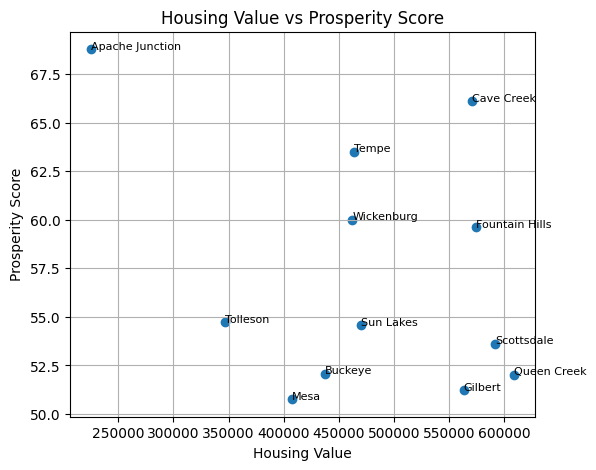

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(top12_df["housing_est"], top12_df["prosperity_index"])

# Add labels
for i, row in top12_df.iterrows():
    plt.text(row["housing_est"], row["prosperity_index"], row["City"], fontsize=8)

plt.xlabel("Housing Value")
plt.ylabel("Prosperity Score")
plt.title("Housing Value vs Prosperity Score")

plt.grid(True)
plt.show()

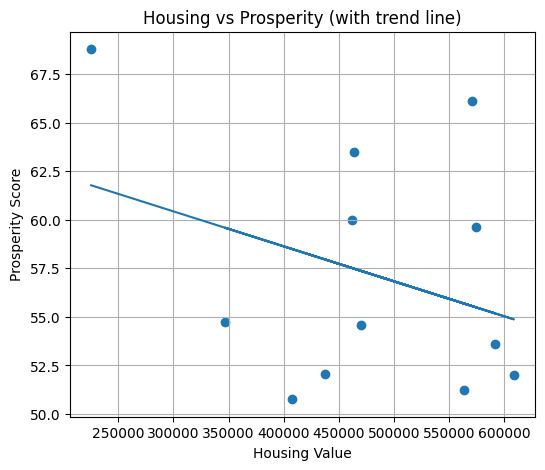

In [ ]:
import numpy as np

x = top12_df["housing_est"]
y = top12_df["prosperity_index"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(6,5))
plt.scatter(x, y)

plt.plot(x, m*x + b)

plt.xlabel("Housing Value")
plt.ylabel("Prosperity Score")
plt.title("Housing vs Prosperity (with trend line)")
plt.grid(True)
plt.show()

In [ ]:
top12_pop = merged_df.sort_values("population_1y_over", ascending=False).head(12).copy()

print("Top 12 cities by population:")
print(top12_pop[["City", "population_1y_over"]])

Top 12 cities by population:
          City  population_1y_over
18     Phoenix           1625143.0
11        Mesa            506004.0
16    Chandler            277540.0
10     Gilbert            277500.0
19    Glendale            249978.0
7   Scottsdale            241921.0
22      Peoria            195038.0
2        Tempe            186400.0
14    Surprise            153384.0
17    Goodyear            106285.0
8      Buckeye            103593.0
20    Avondale             91344.0


In [ ]:
corr = top12_pop["housing_est"].corr(top12_pop["prosperity_index"])

print(f"Correlation between Housing and Prosperity: {corr:.3f}")

Correlation between Housing and Prosperity: 0.241


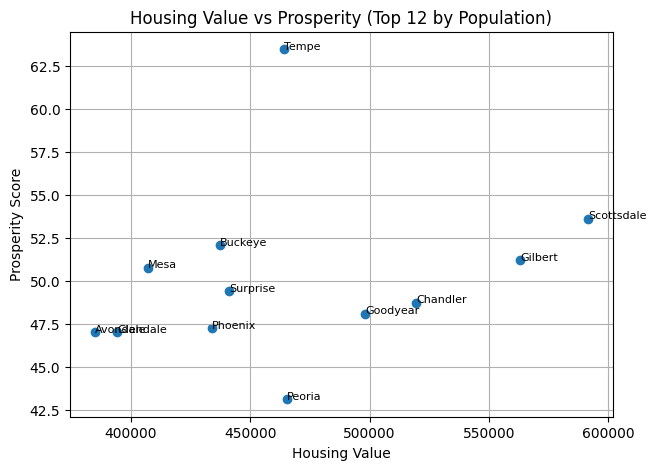

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(top12_pop["housing_est"], top12_pop["prosperity_index"])

# label cities
for i, row in top12_pop.iterrows():
    plt.text(row["housing_est"], row["prosperity_index"], row["City"], fontsize=8)

plt.xlabel("Housing Value")
plt.ylabel("Prosperity Score")
plt.title("Housing Value vs Prosperity (Top 12 by Population)")

plt.grid(True)
plt.show()

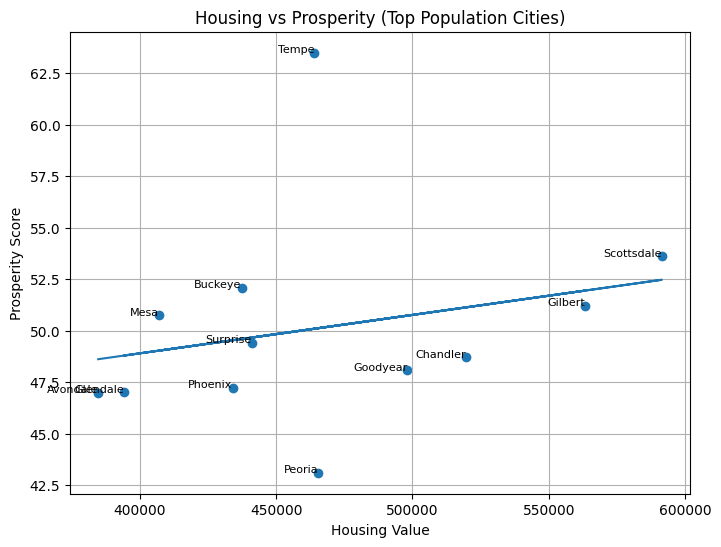

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = top12_pop["housing_est"]
y = top12_pop["prosperity_index"]

# regression line
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,6))
plt.scatter(x, y)

# add regression line
plt.plot(x, m*x + b)

# 🔥 add city labels
for i, row in top12_pop.iterrows():
    plt.text(
        row["housing_est"],
        row["prosperity_index"],
        row["City"],
        fontsize=8,
        ha="right"
    )

plt.xlabel("Housing Value")
plt.ylabel("Prosperity Score")
plt.title("Housing vs Prosperity (Top Population Cities)")

plt.grid(True)
plt.show()

In [ ]:
corr_hp = top12_pop["housing_est"].corr(top12_pop["population_1y_over"])

print(f"Correlation between Housing Value and Population: {corr_hp:.3f}")

Correlation between Housing Value and Population: -0.137


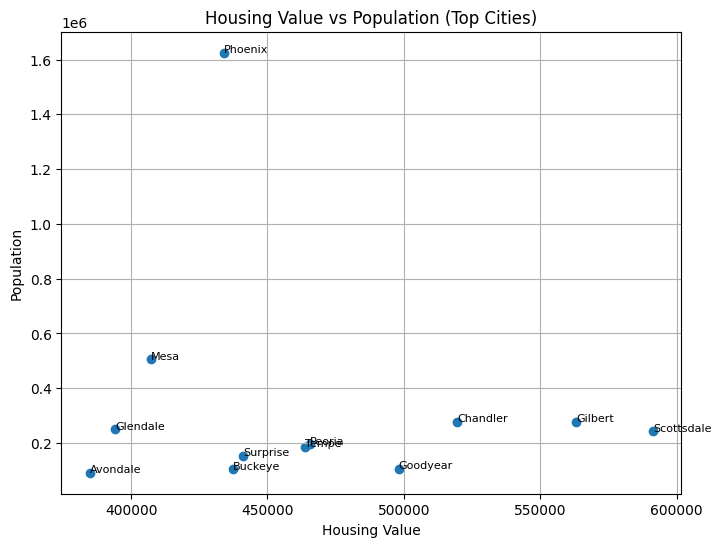

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(top12_pop["housing_est"], top12_pop["population_1y_over"])

# Add city labels
for i, row in top12_pop.iterrows():
    plt.text(
        row["housing_est"],
        row["population_1y_over"],
        row["City"],
        fontsize=8
    )

plt.xlabel("Housing Value")
plt.ylabel("Population")
plt.title("Housing Value vs Population (Top Cities)")

plt.grid(True)
plt.show()

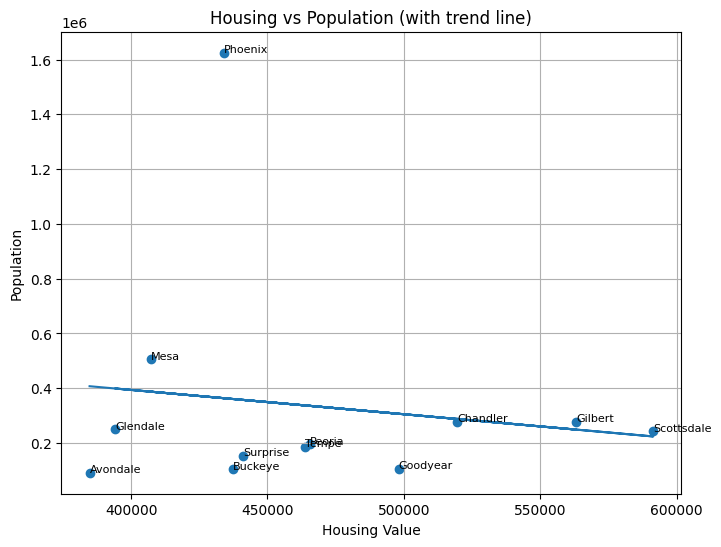

In [ ]:
import numpy as np

x = top12_pop["housing_est"]
y = top12_pop["population_1y_over"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,6))
plt.scatter(x, y)

# regression line
plt.plot(x, m*x + b)

# labels
for i, row in top12_pop.iterrows():
    plt.text(row["housing_est"], row["population_1y_over"], row["City"], fontsize=8)

plt.xlabel("Housing Value")
plt.ylabel("Population")
plt.title("Housing vs Population (with trend line)")

plt.grid(True)
plt.show()

In [ ]:
corr_hp = top12_pop["housing_est"].corr(top12_pop["population_1y_over"])

print("Top 12 Cities (by population):")
print(top12_pop[["City", "population_1y_over", "housing_est"]])

print(f"\nCorrelation (Housing vs Population): {corr_hp:.3f}")

Top 12 Cities (by population):
          City  population_1y_over    housing_est
18     Phoenix           1625143.0  434073.077064
11        Mesa            506004.0  407126.954069
16    Chandler            277540.0  519510.092132
10     Gilbert            277500.0  563187.400221
19    Glendale            249978.0  394127.419096
7   Scottsdale            241921.0  591432.905539
22      Peoria            195038.0  465486.297513
2        Tempe            186400.0  463925.138545
14    Surprise            153384.0  441155.257418
17    Goodyear            106285.0  498146.891005
8      Buckeye            103593.0  437361.051038
20    Avondale             91344.0  384775.466985

Correlation (Housing vs Population): -0.137


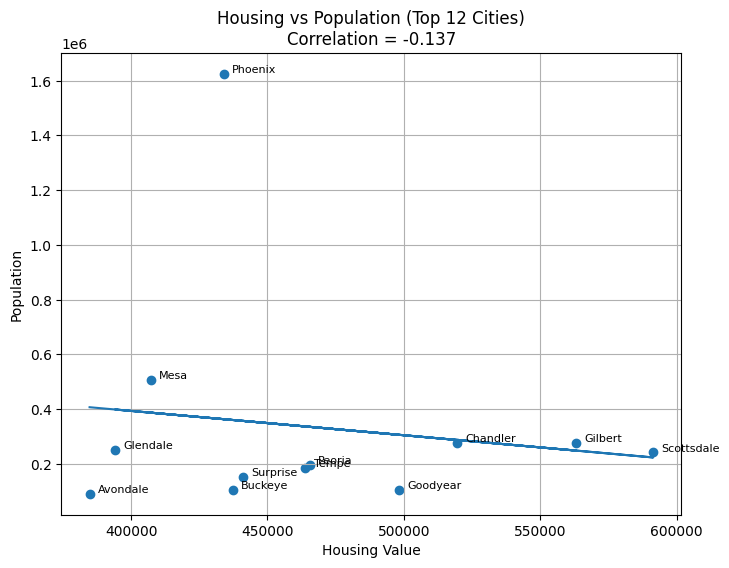

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = top12_pop["housing_est"]
y = top12_pop["population_1y_over"]

# regression line
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,6))
plt.scatter(x, y)

# trend line
plt.plot(x, m*x + b)

# labels
for i, row in top12_pop.iterrows():
    plt.text(
        row["housing_est"] + 3000,
        row["population_1y_over"] + 5000,
        row["City"],
        fontsize=8
    )

plt.xlabel("Housing Value")
plt.ylabel("Population")
plt.title(f"Housing vs Population (Top 12 Cities)\nCorrelation = {corr_hp:.3f}")

plt.grid(True)
plt.show()